In [1]:
# =====================================================
# Import Libraries
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [2]:
# =====================================================
# Load Dataset
# =====================================================

DATA_PATH="../data/raw/ola_rides_100k.csv"

df=pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Booking ID,Booking Date,Booking Time,City,Customer ID,Driver ID,Vehicle Type,Pickup Location,Drop Location,Booking Status,Ride Distance (km),Ride Duration (min),Booking Value,Surge Multiplier,Discount,Payment Method,Weather,Traffic,Driver Rating,Customer Rating,Cancelled by Customer Reason,Cancelled by Driver Reason,Weekend,Hour
0,OLA000001,25-03-2024,16:38:00,Pune,C26989,D7632,Sedan,MG Road,Koramangala,Success,10.53,44,217.95,1.0,0,UPI,Rainy,High,4.5,4.0,NaN,NaN,No,16
1,OLA000002,01-04-2024,14:52:00,Pune,C35331,D6588,Prime Sedan,Electronic City,Yelahanka,Success,11.63,38,266.08,1.0,40,Cash,Cloudy,High,4.6,5.1,NaN,NaN,No,14
2,OLA000003,11-09-2024,01:18:00,Mumbai,C18767,D1455,Sedan,Whitefield,Electronic City,Success,2.06,8,90.90,1.0,60,UPI,Sunny,High,4.5,4.5,NaN,NaN,No,1
3,OLA000004,28-06-2024,23:38:00,Hyderabad,C21721,D1529,Prime SUV,Koramangala,Hebbal,Success,9.12,47,255.04,1.0,60,Card,Sunny,High,3.9,3.9,NaN,NaN,No,23
4,OLA000005,17-03-2024,13:48:00,Hyderabad,C53922,D9618,Auto,Indiranagar,Whitefield,Success,2.74,18,66.99,1.0,0,UPI,Rainy,Low,4.7,6.1,NaN,NaN,Yes,13


In [3]:
# Dataset Shape

print("="*50)

print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

print("="*50)

Rows : 100000
Columns : 24


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Booking ID                    100000 non-null  object 
 1   Booking Date                  100000 non-null  object 
 2   Booking Time                  100000 non-null  object 
 3   City                          100000 non-null  object 
 4   Customer ID                   100000 non-null  object 
 5   Driver ID                     100000 non-null  object 
 6   Vehicle Type                  100000 non-null  object 
 7   Pickup Location               100000 non-null  object 
 8   Drop Location                 100000 non-null  object 
 9   Booking Status                100000 non-null  object 
 10  Ride Distance (km)            100000 non-null  float64
 11  Ride Duration (min)           100000 non-null  int64  
 12  Booking Value                 100000 non-null

In [5]:
# Check Missing Values

missing=df.isnull().sum()

missing

Booking ID                          0
Booking Date                        0
Booking Time                        0
City                                0
Customer ID                         0
Driver ID                           0
Vehicle Type                        0
Pickup Location                     0
Drop Location                       0
Booking Status                      0
Ride Distance (km)                  0
Ride Duration (min)                 0
Booking Value                       0
Surge Multiplier                    0
Discount                            0
Payment Method                      0
Weather                             0
Traffic                             0
Driver Rating                   19861
Customer Rating                 19861
Cancelled by Customer Reason    92062
Cancelled by Driver Reason      93996
Weekend                             0
Hour                                0
dtype: int64

In [6]:
# Missing Value Percentage

missing_percent=(df.isnull().sum()/len(df))*100

missing_report=pd.DataFrame({

"Missing Values":missing,

"Percentage":round(missing_percent,2)

})

missing_report.sort_values(

"Percentage",

ascending=False
)

,Missing Values,Percentage
Cancelled by Driver Reason,93996,94.00
Cancelled by Customer Reason,92062,92.06
Customer Rating,19861,19.86
Driver Rating,19861,19.86
Booking ID,0,0.00
Booking Date,0,0.00
Booking Time,0,0.00
City,0,0.00
Pickup Location,0,0.00
Vehicle Type,0,0.00


In [7]:
# Duplicate Records

duplicates=df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [8]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

print(df.shape)

Duplicates Removed Successfully
(100000, 24)


In [9]:
# Data Types

df.dtypes

Booking ID                       object
Booking Date                     object
Booking Time                     object
City                             object
Customer ID                      object
Driver ID                        object
Vehicle Type                     object
Pickup Location                  object
Drop Location                    object
Booking Status                   object
Ride Distance (km)              float64
Ride Duration (min)               int64
Booking Value                   float64
Surge Multiplier                float64
Discount                          int64
Payment Method                   object
Weather                          object
Traffic                          object
Driver Rating                   float64
Customer Rating                 float64
Cancelled by Customer Reason     object
Cancelled by Driver Reason       object
Weekend                          object
Hour                              int64
dtype: object

In [10]:
# Convert Booking Date

df["Booking Date"]=pd.to_datetime(

df["Booking Date"]

)

print("Booking Date Converted")

Booking Date Converted


In [11]:
# Convert Booking Time

df["Booking Time"]=pd.to_datetime(

df["Booking Time"],

format="%H:%M:%S"

).dt.time

print("Booking Time Converted")

Booking Time Converted


In [12]:
# Booking Value

df["Booking Value"]=pd.to_numeric(

df["Booking Value"],

errors="coerce"

)

In [13]:
# Ride Distance

df["Ride Distance (km)"]=pd.to_numeric(

df["Ride Distance (km)"],

errors="coerce"

)

In [14]:
# Ride Duration

df["Ride Duration (min)"]=pd.to_numeric(

df["Ride Duration (min)"],

errors="coerce"

)

In [15]:
# Driver Rating

df["Driver Rating"]=pd.to_numeric(

df["Driver Rating"],

errors="coerce"

)

In [16]:
# Customer Rating

df["Customer Rating"]=pd.to_numeric(

df["Customer Rating"],

errors="coerce"

)

In [17]:
# Check Numeric Columns

numeric_columns=df.select_dtypes(

include=np.number

).columns

numeric_columns

Index(['Ride Distance (km)', 'Ride Duration (min)', 'Booking Value',
       'Surge Multiplier', 'Discount', 'Driver Rating', 'Customer Rating',
       'Hour'],
      dtype='object')

In [18]:
# Check Categorical Columns

categorical_columns=df.select_dtypes(

include="object"

).columns

categorical_columns

Index(['Booking ID', 'Booking Time', 'City', 'Customer ID', 'Driver ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Booking Status',
       'Payment Method', 'Weather', 'Traffic', 'Cancelled by Customer Reason',
       'Cancelled by Driver Reason', 'Weekend'],
      dtype='object')

In [19]:
# Booking Status

df["Booking Status"].value_counts()

Booking Status
Success                  80139
Cancelled by Customer     7938
Cancelled by Driver       6004
Incomplete                2985
No Driver Found           2934
Name: count, dtype: int64

In [20]:
# Vehicle Type

df["Vehicle Type"].value_counts()

Vehicle Type
Bike           20180
Sedan          18074
Auto           17797
Mini           17046
Prime Sedan    14967
Prime SUV      11936
Name: count, dtype: int64

In [21]:
# Payment Method

df["Payment Method"].value_counts()

Payment Method
UPI       49979
Cash      19972
Card      19904
Wallet    10145
Name: count, dtype: int64

In [22]:
# Weather

df["Weather"].value_counts()

Weather
Sunny     55226
Cloudy    19978
Rainy     19753
Fog        5043
Name: count, dtype: int64

In [23]:
# Traffic

df["Traffic"].value_counts()

Traffic
Medium    44873
Low       29896
High      25231
Name: count, dtype: int64

In [24]:
# Check Null Ratings

print("Driver Rating Missing")

print(df["Driver Rating"].isnull().sum())

print()

print("Customer Rating Missing")

print(df["Customer Rating"].isnull().sum())

Driver Rating Missing
19861

Customer Rating Missing
19861


In [25]:
# Verify that missing ratings are from non-success rides

df.loc[
df["Driver Rating"].isnull(),
"Booking Status"
].value_counts()

Booking Status
Cancelled by Customer    7938
Cancelled by Driver      6004
Incomplete               2985
No Driver Found          2934
Name: count, dtype: int64

In [26]:
# Missing Booking Value

df["Booking Value"].isnull().sum()

np.int64(0)

In [27]:
# Missing Ride Distance

df["Ride Distance (km)"].isnull().sum()

np.int64(0)

In [28]:
# Save Intermediate Copy

df.to_csv(

"../data/processed/intermediate_dataset.csv",

index=False

)

print("Intermediate Dataset Saved")

Intermediate Dataset Saved


In [29]:
# ==========================================
# Create Day
# ==========================================

df["Day"] = df["Booking Date"].dt.day

print("Day Created")

Day Created


In [30]:
# ==========================================
# Month
# ==========================================

df["Month"] = df["Booking Date"].dt.month_name()

print("Month Created")

Month Created


In [31]:
# ==========================================
# Year
# ==========================================

df["Year"] = df["Booking Date"].dt.year

In [32]:
# ==========================================
# Weekday
# ==========================================

df["Weekday"] = df["Booking Date"].dt.day_name()

In [33]:
# ==========================================
# Quarter
# ==========================================

df["Quarter"] = df["Booking Date"].dt.quarter

In [34]:
# ==========================================
# Extract Hour
# ==========================================

df["Hour"] = pd.to_datetime(
    df["Booking Time"].astype(str)
).dt.hour

In [35]:
# ==========================================
# Weekend
# ==========================================

df["Weekend"] = np.where(
    df["Weekday"].isin(["Saturday","Sunday"]),
    "Yes",
    "No"
)

In [36]:
# ==========================================
# Peak Hour
# ==========================================

def peak_hour(hour):

    if 7 <= hour <= 10:
        return "Morning Peak"

    elif 17 <= hour <= 21:
        return "Evening Peak"

    else:
        return "Normal"

df["Peak Hour"] = df["Hour"].apply(peak_hour)

In [37]:
# ==========================================
# Time Of Day
# ==========================================

def time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df["Time Of Day"] = df["Hour"].apply(time_period)

In [38]:
# ==========================================
# Fare Per KM
# ==========================================

df["Fare Per KM"] = round(
    df["Booking Value"] /
    df["Ride Distance (km)"],
    2
)

In [39]:
# Replace infinite values

df["Fare Per KM"] = df["Fare Per KM"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [40]:
# ==========================================
# Booking Value Category
# ==========================================

df["Booking Category"] = pd.cut(

    df["Booking Value"],

    bins=[0,300,700,1200,np.inf],

    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

In [41]:
# ==========================================
# Distance Category
# ==========================================

df["Distance Category"] = pd.cut(

    df["Ride Distance (km)"],

    bins=[0,5,10,20,100],

    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

In [42]:
# ==========================================
# Rating Category
# ==========================================

def rating_group(rating):

    if pd.isna(rating):
        return "Not Rated"

    elif rating >= 4.5:
        return "Excellent"

    elif rating >= 4:
        return "Good"

    elif rating >= 3:
        return "Average"

    else:
        return "Poor"

df["Driver Rating Category"] = df["Driver Rating"].apply(rating_group)

df["Customer Rating Category"] = df["Customer Rating"].apply(rating_group)

In [43]:
numeric_columns = [

    "Booking Value",

    "Ride Distance (km)",

    "Ride Duration (min)"

]

df[numeric_columns].describe()

,Booking Value,Ride Distance (km),Ride Duration (min)
count,100000.000000,100000.000000,100000.000000
mean,186.276670,8.808472,47.894360
std,101.417529,5.924771,35.842492
min,33.000000,1.000000,3.000000
25%,114.300000,4.420000,22.000000
50%,165.410000,7.510000,39.000000
75%,236.000000,11.770000,64.000000
max,1246.880000,64.370000,387.000000


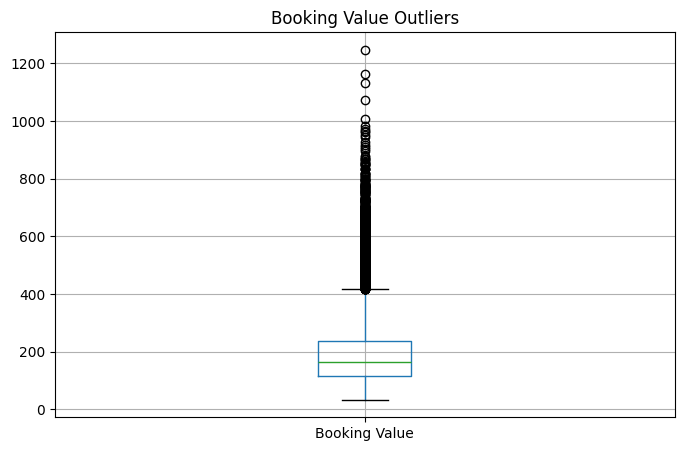

In [44]:
plt.figure(figsize=(8,5))

df.boxplot(column="Booking Value")

plt.title("Booking Value Outliers")

plt.show()

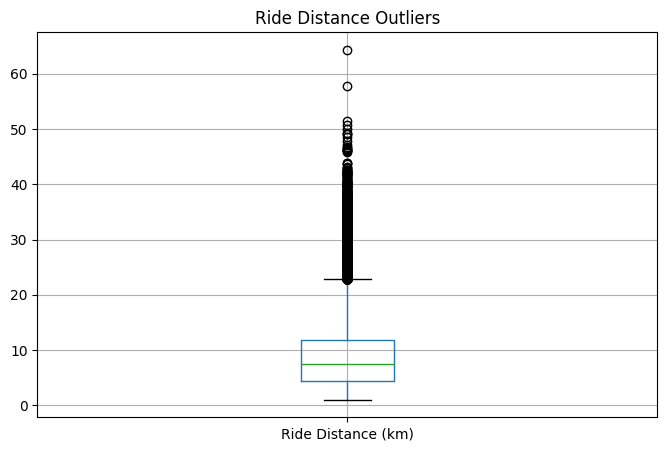

In [45]:
plt.figure(figsize=(8,5))

df.boxplot(column="Ride Distance (km)")

plt.title("Ride Distance Outliers")

plt.show()

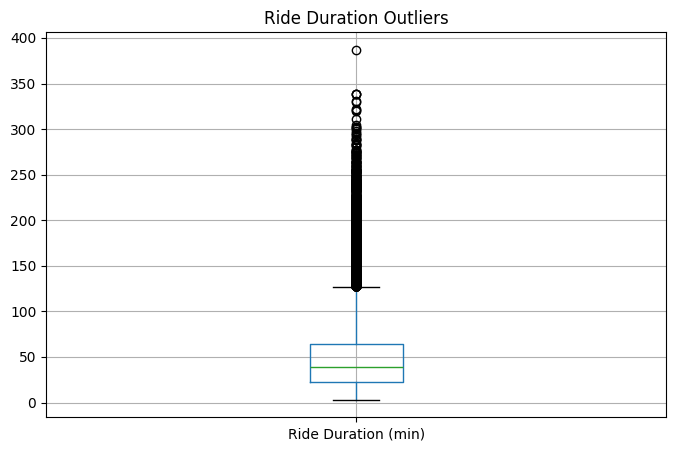

In [46]:
plt.figure(figsize=(8,5))

df.boxplot(column="Ride Duration (min)")

plt.title("Ride Duration Outliers")

plt.show()

In [47]:
summary = {

    "Original Rows":100000,

    "Final Rows":len(df),

    "Columns":len(df.columns),

    "Duplicates Removed":duplicates,

    "Missing Values Remaining":df.isnull().sum().sum()

}

summary

{'Original Rows': 100000,
 'Final Rows': 100000,
 'Columns': 36,
 'Duplicates Removed': np.int64(0),
 'Missing Values Remaining': np.int64(225780)}

In [48]:
summary_df = pd.DataFrame(

summary.items(),

columns=["Metric","Value"]

)

summary_df

,Metric,Value
0,Original Rows,100000
1,Final Rows,100000
2,Columns,36
3,Duplicates Removed,0
4,Missing Values Remaining,225780


In [49]:
summary_df.to_csv(

"../reports/data_cleaning_summary.csv",

index=False

)

In [50]:
df.to_csv(

"../data/cleaned/ola_cleaned.csv",

index=False

)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


In [51]:
print("="*60)

print("DATA CLEANING COMPLETED SUCCESSFULLY")

print("="*60)

print(f"Rows : {df.shape[0]}")

print(f"Columns : {df.shape[1]}")

print(f"Duplicate Rows Removed : {duplicates}")

print(f"Missing Values : {df.isnull().sum().sum()}")

print("="*60)

DATA CLEANING COMPLETED SUCCESSFULLY
Rows : 100000
Columns : 36
Duplicate Rows Removed : 0
Missing Values : 225780
